In [1]:
# Imports de utilidades de análisis
import pandas as pd
import numpy as np

# For 3d viz
import matplotlib.pyplot as plt 
import plotly.graph_objects as go



In [2]:
from mammo_prep import load_dicom, normalize_to_uint8, apply_clahe
from mammo_prep import flip_to_standard, crop_breast, resize_long_side, pad_to_square
from mammo_prep import show, plot_comparison


In [3]:
DICOM_BASE = "/mnt/cafetera/mammo/vindr/images"
ANNOTATIONS = "/home/enric_sena/Desktop/prova_enric/vindr_dataset/finding_annotations.csv"

In [6]:


annotations = pd.read_csv(ANNOTATIONS)
df=annotations # per practicitat més endavant
df.head()

sample_images = df[df["xmin"].notna()][['study_id','image_id']].drop_duplicates().sample(1)


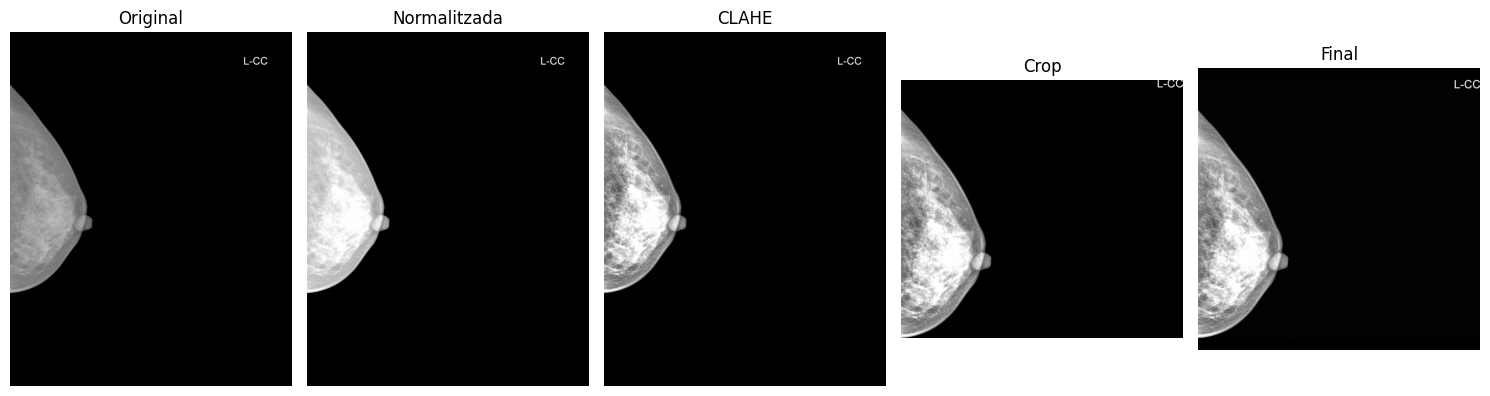

In [7]:
for _, row in sample_images.iterrows():
    path = f"{DICOM_BASE}/{row['study_id']}/{row['image_id']}.dicom"
    
    img, ds = load_dicom(path)
    img_flip = flip_to_standard(img, ds)
    img_norm = normalize_to_uint8(img_flip)
    img_clahe = apply_clahe(img_norm)
    img_crop, mask = crop_breast(img_clahe)
    img_resized = resize_long_side(img_crop)
    img_final = pad_to_square(img_resized)
    
    plot_comparison(
        [img,img_norm, img_clahe, img_crop, img_final],
        titles=["Original","Normalitzada", "CLAHE", "Crop", "Final"]
)

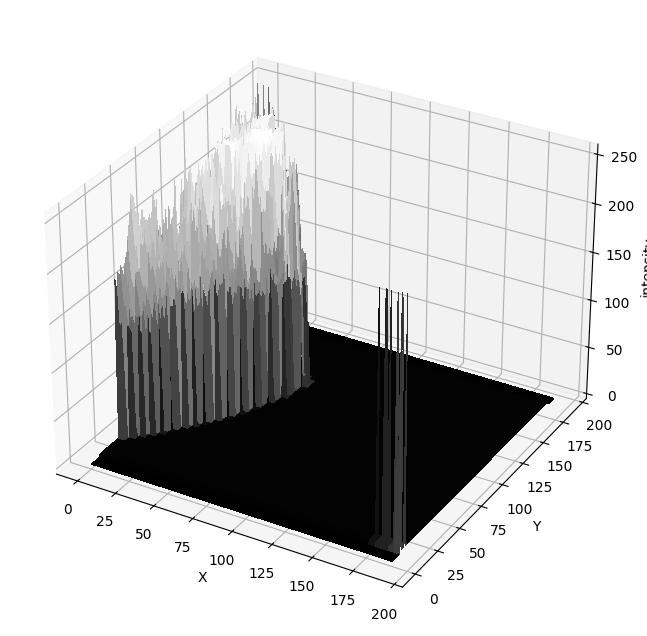

In [14]:
## 3D visualization

step = 8
img_small = img_final[::step, ::step]

x = np.arange(img_small.shape[1])
y = np.arange(img_small.shape[0])

X,Y = np.meshgrid(x,y)

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    X,
    Y,
    img_small,
    cmap='gray',
    linewidth=0,
    antialiased=False
)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('intensity')
plt.show()


In [16]:

step = 4
img_small = img_final[::step, ::step]

fig = go.Figure(
    data=[
        go.Surface(
            z=img_small,
            colorscale="Gray"
        )
    ]
)

fig.update_layout(
    title="Mammography Intensity Surface",
    width=900,
    height=800
)
fig.write_html("mammo_post_3d.html")
